In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (2.5,2.5)
import seaborn as sns
import statsmodels.api as sm

save = False

print(mpl.__version__, pd.__version__)

3.10.9 2.3.3


# Data loading

In [2]:
sumstat_ukb_f = 'release/ml-burden.sumstats.parquet'
sumstat_aou_f = 'release/ml-burden.sumstats.aou.parquet'

ANNO_ORDER = ['ESM1B','AM','GPN','CADD16','CADD17']
TEST_ORDER1 = ['BURDEN','SKAT-O','SKAT','ACATV']
TEST_ORDER2 = ['BURDEN-SBAT','BURDEN-ACAT','SKATO-ACAT','ACATV-ACAT','GENE_P']
TEST_ORDER = TEST_ORDER1 + TEST_ORDER2
GROUP_ORDER = ['Ocular','Pulmonary','Anthropometric','Height']

In [3]:
# summary stats
sumstats = pd.concat(
    [
        pd.read_parquet(sumstat_ukb_f),
        pd.read_parquet(sumstat_aou_f),
    ],
    axis=0
).dropna(
    subset=['anno']
)

sumstats['anno'] = sumstats['anno'].str.upper()
sumstats['anno'] = sumstats['anno'].replace({'ESM':'ESM1B'})

pheno_groups = {
    'height': 'Height',
    'height_aou': 'Height',
    'weight': 'Anthropometric',
    'weight_aou': 'Anthropometric',
    'bmi': 'Anthropometric',
    'bmi_aou': 'Anthropometric',
    'fev1': 'Pulmonary',
    'fvc': 'Pulmonary',
    'fev1_fvc_ratio': 'Pulmonary',
    'iop-R': 'Ocular',
    'iop-L': 'Ocular',
    'iop-G-R': 'Ocular',
    'iop-G-L': 'Ocular',
    'ch-R': 'Ocular',
    'ch-L': 'Ocular',
    'crf-R': 'Ocular',
    'crf-L': 'Ocular'
}

pheno2code = {
    'bmi': '21001',
    'bmi_aou': '21001',
    'ch-L': '5264',
    'ch-R': '5256',
    'crf-L': '5265',
    'crf-R': '5257',
    'fev1': '3063',
    'fev1_fvc_ratio': '20258',
    'fvc': '3062',
    'height': '50',
    'height_aou': '50',
    'iop-G-L': '5263', 
    'iop-G-R': '5255',
    'iop-L': '5262',
    'iop-R': '5254',
    'weight': '21002',
    'weight_aou': '21002',
}

sumstats['pheno_group'] = sumstats['pheno'].apply(pheno_groups.get)
sumstats['pheno_code'] = sumstats['pheno'].apply(pheno2code.get)

sumstats.head(3)

,CHROM,GENPOS,GENE,gene_id,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,pheno,anno,mask,test_keys,pop_sample,pheno_group,pheno_code
0,1.0,925946.0,SAMD11,ENSG00000187634,NaN,282956,ADD-ACATV,NaN,NaN,0.801595,0.431075,fev1_fvc_ratio,CADD16,del,ACATV,related,Pulmonary,20258
1,1.0,925946.0,SAMD11,ENSG00000187634,NaN,282956,ADD-SKAT,NaN,NaN,1.944740,0.787401,fev1_fvc_ratio,CADD16,del,SKAT,related,Pulmonary,20258
2,1.0,925946.0,SAMD11,ENSG00000187634,NaN,282956,ADD-SKATO-ACAT,NaN,NaN,1.909740,0.777305,fev1_fvc_ratio,CADD16,del,SKAT-O,related,Pulmonary,20258


# Analysis

## Replications

In [4]:
aou_rep = sumstats.loc[(
    sumstats['pheno_code'].isin(['21001', '21002', '50'])
) & (
    sumstats['pop_sample'] == 'related'
) & (
    sumstats['mask'].isin(['del','bdm'])
) & (
    sumstats['LOG10P'] > 4
), :].groupby(
    ['test_keys','anno','pheno_code','gene_id']
)['N'].count()

inner = aou_rep.reset_index().query('N == 2').groupby(['test_keys','anno'])['gene_id'].count()
outer = aou_rep.reset_index().query('N == 1').groupby(['test_keys','anno'])['gene_id'].count()

/tmp/slurmjob.58068303/ipykernel_2146103/1962961464.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([None for _ in ax.get_yticklabels()]);


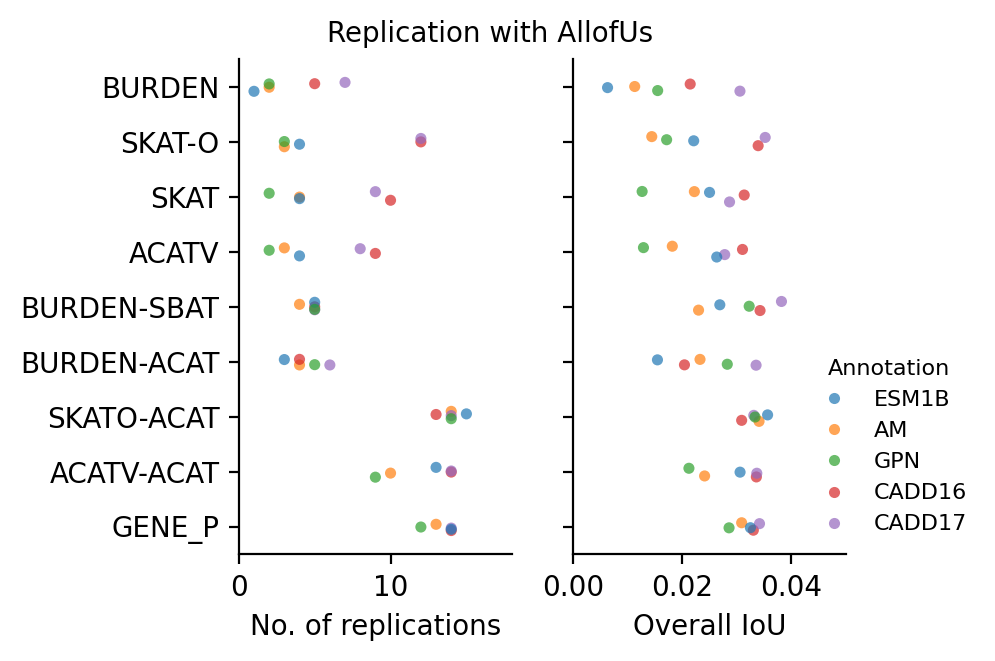

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3.5), dpi=200)

ax = axs[0]

sns.stripplot(
    data = inner.reset_index(),
    ax = ax,
    x = 'gene_id',
    y = 'test_keys',
    hue = 'anno',
    order = TEST_ORDER,
    hue_order = ANNO_ORDER,
    s = 4,
    alpha = 0.7,
    legend = None,
);
ax.set_xlabel('No. of replications');
ax.set_ylabel(None);
ax.set_xlim(0, 18);

ax = axs[1]
sns.stripplot(
    data = (inner / outer).reset_index(),
    ax = ax,
    x = 'gene_id',
    y = 'test_keys',
    hue = 'anno',
    order = TEST_ORDER,
    hue_order = ANNO_ORDER,
    s = 4,
    alpha = 0.7,
);
ax.set_xlabel('Overall IoU');
ax.set_yticklabels([None for _ in ax.get_yticklabels()]);
ax.set_ylabel(None);
ax.set_xlim(0, 0.05);

ax.legend(frameon=0, title='Annotation', fontsize=8, title_fontsize=8, bbox_to_anchor=(0.8, 0.0), loc='lower left');

fig.suptitle('Replication with AllofUs', fontsize=10, y=0.93);
fig.tight_layout();
sns.despine();

if save:
    plt.savefig('png/supplement/AoU_rep.png');

## Separate counts

In [6]:
ukb_cts = sumstats.loc[(
    sumstats['pheno'].isin(['bmi','weight','height'])
) & (
    sumstats['pop_sample'] == 'related'
) & (
    sumstats['mask'].isin(['del','bdm'])
) & (
    sumstats['LOG10P'] > 4
) & (
    sumstats['test_keys'] != 'COAST_O'
), :].groupby(
    ['test_keys','anno','pheno_code']
)['N'].count()

aou_cts = sumstats.loc[(
    sumstats['pheno'].isin(['bmi_aou','weight_aou','height_aou'])
) & (
    sumstats['pop_sample'] == 'related'
) & (
    sumstats['mask'].isin(['del','bdm'])
) & (
    sumstats['LOG10P'] > 4
), :].groupby(
    ['test_keys','anno','pheno_code']
)['N'].count()

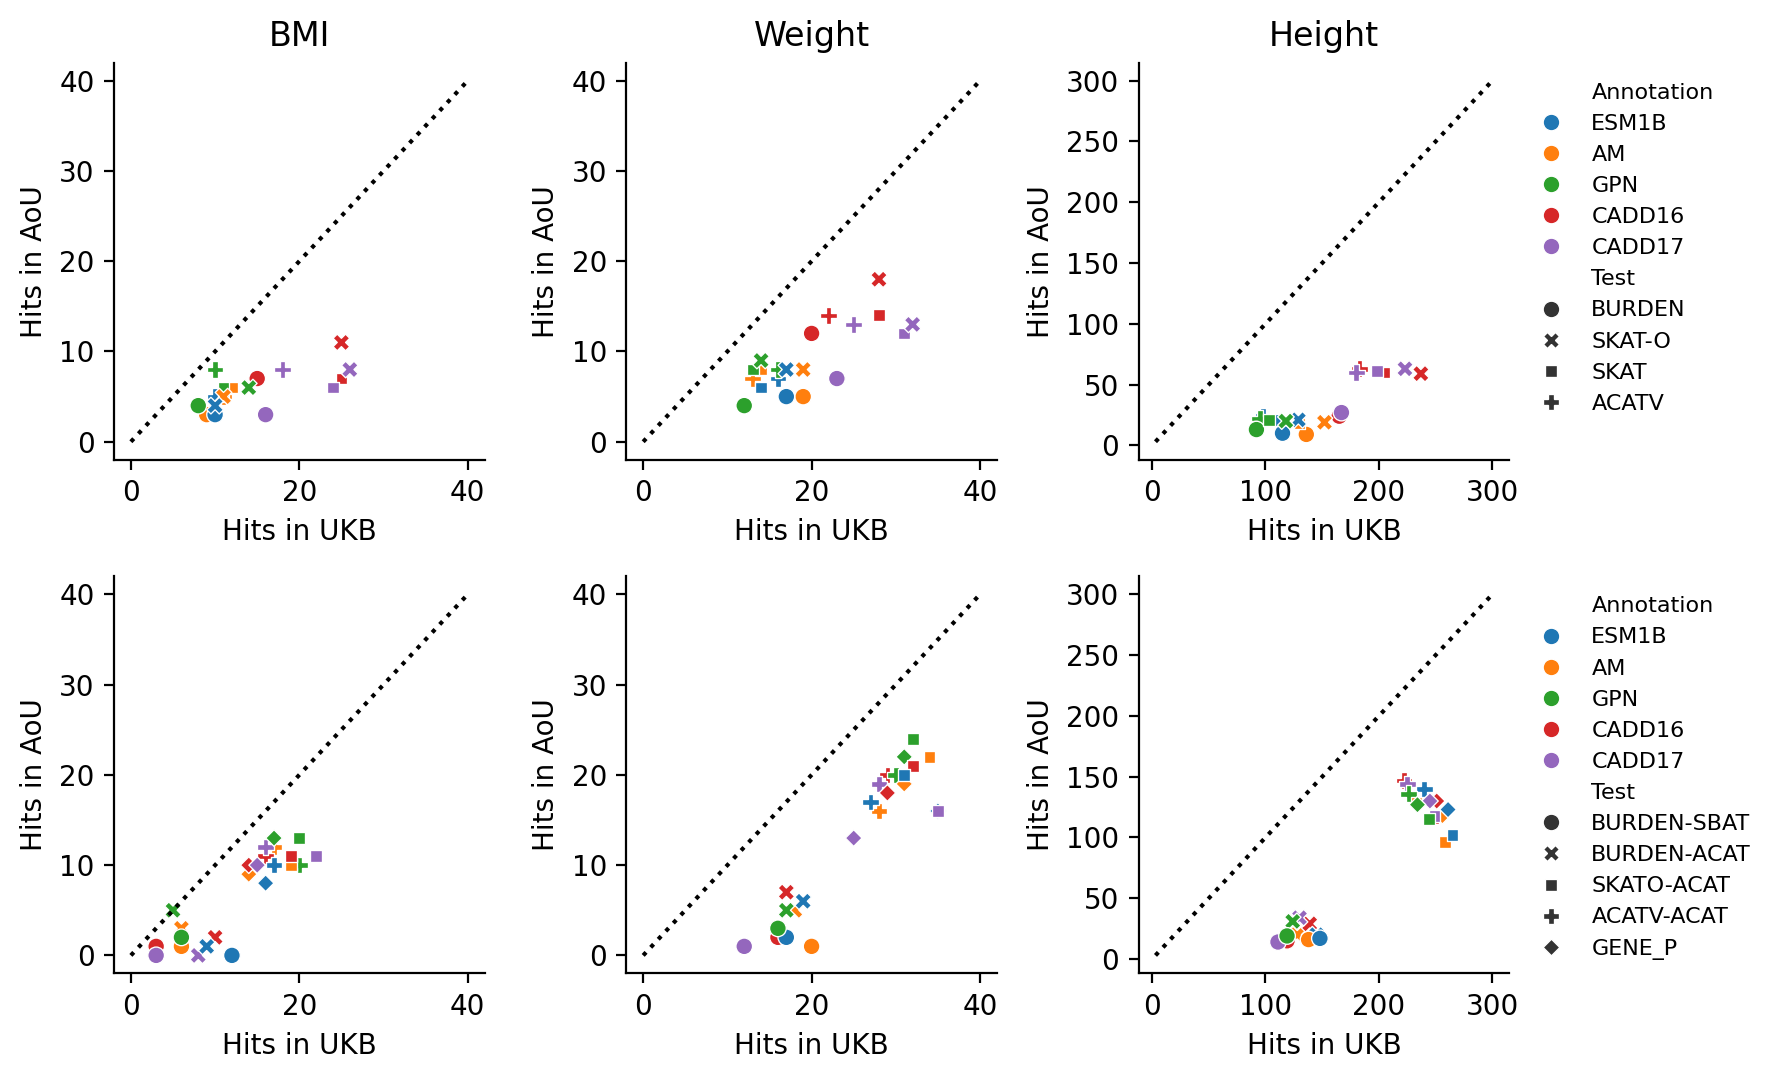

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(9, 5.5), dpi=200)

for i,(ax,code,name) in enumerate(zip(
        axs.flat, 
        ('21001','21002','50','21001','21002','50'), 
        ('BMI','Weight','Height','BMI','Weight','Height')
    )):

    this_test_order = TEST_ORDER[:4] if i < 3 else TEST_ORDER[4:]
    sns.scatterplot(
        ax = ax,
        data = pd.concat(
            [
                ukb_cts.rename('Hits in UKB'), 
                aou_cts.rename('Hits in AoU')
            ], 
            axis=1
        ).fillna(0).query(
            'pheno_code == @code & test_keys.isin(@this_test_order)'
        ).reset_index().rename(
            {'anno':'Annotation', 'test_keys':'Test'}, axis=1
        ),
        x = 'Hits in UKB',
        y = 'Hits in AoU',
        style = 'Test',
        style_order = this_test_order,
        hue = 'Annotation',
        hue_order = ANNO_ORDER,
        legend = (i == 2 or i == 5),
    );
    
    if i == 2 or i == 5:
        ax.legend(frameon=0, fontsize=8, bbox_to_anchor=(1.0, 1.0), loc='upper left');
        #ax.loglog();
        ax.plot([3, 300], [3, 300], 'k:');
    else:
        ax.plot([0, 40], [0, 40], 'k:');
        
    ax.set_title(name if i < 3 else '');

fig.tight_layout();
sns.despine();

if save:
    plt.savefig('png/supplement/AoU_UKB_cts.png');

## ANOVA

In [8]:
for df,stat in zip([inner, inner / outer], ['Count', 'IoU']):
    for t,test in zip([TEST_ORDER1, TEST_ORDER2], ['primary','secondary']):
        for a,b in [('anno','test_keys'),('test_keys','anno')]:
            print('{0} ~ {1}, {2}'.format(stat, a, test))
            print(
                sm.stats.AnovaRM(
                    data=df.reset_index().query('test_keys.isin(@t)'),
                    depvar='gene_id', 
                    subject=b, 
                    within=[a]
                ).fit().anova_table#.as_latex()
            )
            print()

Count ~ anno, primary
       F Value  Num DF  Den DF    Pr > F
anno  29.31746     4.0    12.0  0.000004

Count ~ test_keys, primary
           F Value  Num DF  Den DF    Pr > F
test_keys  6.47619     3.0    12.0  0.007448

Count ~ anno, secondary
       F Value  Num DF  Den DF    Pr > F
anno  1.684932     4.0    16.0  0.202511

Count ~ test_keys, secondary
             F Value  Num DF  Den DF        Pr > F
test_keys  76.684932     4.0    16.0  3.139138e-10

IoU ~ anno, primary
      F Value  Num DF  Den DF    Pr > F
anno  9.43113     4.0    12.0  0.001097

IoU ~ test_keys, primary
            F Value  Num DF  Den DF    Pr > F
test_keys  2.633015     3.0    12.0  0.097761

IoU ~ anno, secondary
       F Value  Num DF  Den DF    Pr > F
anno  2.053366     4.0    16.0  0.134993

IoU ~ test_keys, secondary
            F Value  Num DF  Den DF    Pr > F
test_keys  3.108417     4.0    16.0  0.045221



In [9]:
inner_h = aou_rep.reset_index().query(
    'N == 2 & pheno_code == "50"'
).groupby(['test_keys','anno'])['gene_id'].count()
outer_h = aou_rep.reset_index().query(
    'N == 1 & pheno_code == "50"'
).groupby(['test_keys','anno'])['gene_id'].count()

In [10]:
for df,stat in zip([inner_h, inner_h / outer_h], ['Count', 'IoU']):
    for t,test in zip([TEST_ORDER1, TEST_ORDER2], ['primary','secondary']):
        for a,b in [('anno','test_keys'),('test_keys','anno')]:
            print('{0} ~ {1}, {2}'.format(stat, a, test))
            print(
                sm.stats.AnovaRM(
                    data=df.reset_index().query('test_keys.isin(@t)'),
                    depvar='gene_id', 
                    subject=b, 
                    within=[a]
                ).fit().summary()#.as_latex()
            )

Count ~ anno, primary
              Anova
     F Value Num DF  Den DF Pr > F
----------------------------------
anno 35.7227 4.0000 12.0000 0.0000

Count ~ test_keys, primary
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
test_keys  9.2773 3.0000 12.0000 0.0019

Count ~ anno, secondary
              Anova
     F Value Num DF  Den DF Pr > F
----------------------------------
anno  3.2277 4.0000 16.0000 0.0402

Count ~ test_keys, secondary
                 Anova
          F Value  Num DF  Den DF Pr > F
----------------------------------------
test_keys 113.3267 4.0000 16.0000 0.0000

IoU ~ anno, primary
              Anova
     F Value Num DF  Den DF Pr > F
----------------------------------
anno 12.3667 4.0000 12.0000 0.0003

IoU ~ test_keys, primary
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
test_keys  7.5096 3.0000 12.0000 0.0043

IoU ~ anno, secondary
              Anov